# SarcGraphTools - TimeSeries

All demos are availble on GitHub at https://github.com/Sarc-Graph/sarcgraph/tree/main/tutorials.

To run demos with `jupyter notebook` check [Installation Guide](https://sarc-graph.readthedocs.io/en/latest/installation.html).

SarcGraph applies Gaussian Process Regression (GPR) on the recovered sarcomere characteristics to reduce the noise and predict values for missing frames.

In this notebook we provide a tutorial on how to use the SarcGraph package using demos and examples. The focus is on the ``SarcGraphTools.TimeSeries`` class in the ``sg_tools`` module.

## Initialization

Methods in the ``SarcGraphTools`` class need the information that will be saved by running ``SarcGraph.sarcomere_detection()``.

To showcase this we use ``samples/sample_1.avi``.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sarcgraph.sg import SarcGraph

sg = SarcGraph(output_dir='../tutorial-results', input_type='video')
sarcomeres, _ = sg.sarcomere_detection(input_file='../samples/sample_1.avi')

sarcomeres.sample(5)

Frame 79: 91 trajectories present.


,frame,sarc_id,x,y,length,width,angle,zdiscs
5752,72,71,154.409249,189.212740,10.739952,10.017832,2.133358,"68,89"
6680,40,83,157.867831,193.120419,10.447597,9.863638,1.966047,"84,89"
5925,5,74,198.868706,155.165070,16.323567,8.542900,0.193777,"71,74"
1519,79,18,122.711380,361.688524,22.985585,23.885546,2.293599,"-26,-23"
6370,50,79,179.125075,190.661982,11.538721,10.738732,1.043824,"78,81"


By dafault ``save_output=True`` in ``sg.sarcomere_detection()`` and the following information will be saved in ``../tutorial-results``:

- raw video frames (grayscale)
- filtered video frames
- zdisc contours
- segmented zdiscs information
- tracked zdiscs information
- detected sarcomeres information

## Gaussian Process Regression (GPR)

In the subsequent step, following the execution of ``sg.sarcomere_detection()``, we employ the ``SarcGraphTools.TimeSeries`` class to perform Gaussian Process Regression (GPR) on the extracted sarcomere features. This serves two primary objectives: (1) mitigating noise in the time series data, and (2) estimating values for absent data in certain frames. It is crucial to note that without this step, the methods within the ``Analysis`` class in ``SarcGraphTools`` will be rendered inoperative.

<div class="alert alert-warning">
<strong>Warning:</strong> This process may take a long time depending on the number of frames and sarcomeres.
</div>

In [3]:
from sarcgraph import SarcGraphTools

sg_tools = SarcGraphTools(input_dir='../tutorial-results')
sarcomeres_gpr = sg_tools.time_series.sarcomeres_gpr()

sarcomeres_gpr.sample(5)

,frame,sarc_id,x,y,length,width,angle,zdiscs,length_norm
4977,17,62,257.504357,172.804000,13.917061,9.946566,0.418171,"38,39",-0.033485
3363,3,42,249.132561,257.640095,16.938411,9.234651,2.498005,"2,23",0.032251
4142,62,51,217.879109,305.880888,14.640984,8.779329,1.166192,"11,18",-0.015021
6242,2,78,181.257809,134.148465,13.301387,9.334941,1.579719,"77,82",-0.053457
3264,64,40,250.144768,284.895813,17.111651,9.893308,0.622797,"1,42",0.037646


Through this illustration, we demonstrate the efficacy of Gaussian Process Regression (GPR) in minimizing noise associated with the detected length of a specific sarcomere across multiple frames.

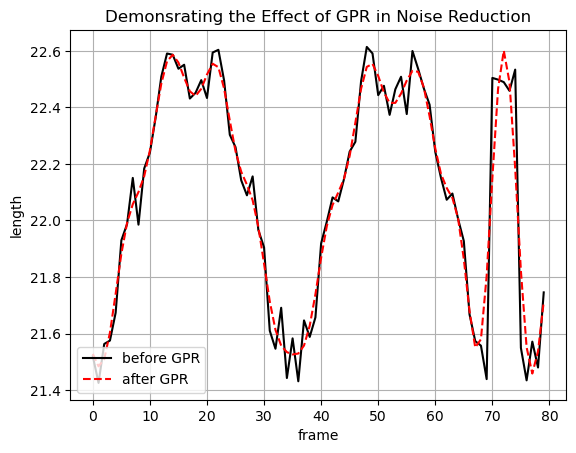

In [4]:
import matplotlib.pyplot as plt

ax = plt.axes()
ax.grid('on')
ax.set_title('Demonsrating the Effect of GPR in Noise Reduction')
ax.set_ylabel('length')
ax.set_xlabel('frame')

# Note that sarcomeres contrains information of detected sarcomeres before GPR
# and sarcomeres_gpr contains the same information after applying GPR
plt.plot(sarcomeres[sarcomeres.sarc_id == 1].length.to_numpy(), color='k', label='before GPR')
plt.plot(sarcomeres_gpr[sarcomeres_gpr.sarc_id == 1].length.to_numpy(), 'r--', label='after GPR')

plt.legend()

To show the effect of GPR on missing data prediction, we use a different video sample ``samples/sample_2.avi``.

In [5]:
sg = SarcGraph(output_dir='../tutorial-results-2', input_type='video')
sarcomeres, _ = sg.sarcomere_detection(input_file='../samples/sample_2.avi')

sg_tools = SarcGraphTools(input_dir='../tutorial-results-2')
sarcomeres_gpr = sg_tools.time_series.sarcomeres_gpr()

Frame 145: 614 trajectories present.


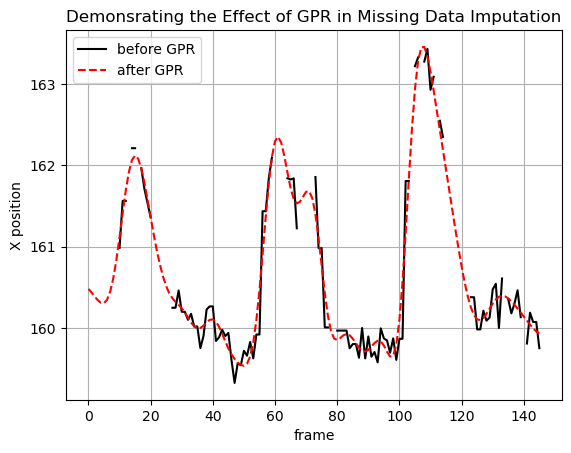

In [56]:
import matplotlib.pyplot as plt

ax = plt.axes()
ax.grid('on')
ax.set_title('Demonsrating the Effect of GPR in Missing Data Imputation')
ax.set_ylabel('X position')
ax.set_xlabel('frame')

# Note that sarcomeres contrains information of detected sarcomeres before GPR
# and sarcomeres_gpr contains the same information after applying GPR
plt.plot(sarcomeres[sarcomeres.sarc_id == 3].x.to_numpy(), color='k', label='before GPR')
plt.plot(sarcomeres_gpr[sarcomeres_gpr.sarc_id == 3].x.to_numpy(), 'r--', label='after GPR')

plt.legend()

This saves sarcomeres info with GPR as ``sarcomeres_gpr.csv`` in the specified input directory ``input_dir`` if ``save_results=True`` in ``SarcGraphTools``.

**Note**

Additionally, ``sarcomeres_gpr()`` computes normalized length for each sarcomeres over all frames into ``length_norm`` column.